### A Data-Driven Study of Electric Vehicle Adoption, Range, and Evolution"

In [1]:
import numpy as np 
import pandas as pd 

In [2]:
import seaborn as sns 

In [3]:
# load the csv file 
# pd.read_csv(r " path of csv file")
# r means : raw string 
data = pd.read_csv(r"C:\Users\bajaj\OneDrive\Desktop\Anna\Dataset\Electric_Vehicle_Population_Data.csv")

In [5]:
data.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,1593721,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
1,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,257167501,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
2,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,224071816,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
3,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,260084653,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
4,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,253771913,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


### #Problem Statement 

In [6]:
'''
This project aims to perform exploratory data analysis
and machine learning on electric vehicle  data in the U.S. and India 
to uncover trends in EV adoption over the years,
evaluate manufacturer-wise electric range performance,
and build predictive models to classify 
and estimate the electric range , price , charger type , demand of charging stations of Electric vehicles based on attributes like manufacturers, model year, available charging stations , known charger type , weather conditions of the region 
etc. The analysis will also identify missing data patterns, detect top-performing EVs, 
and help understand how electric vehicle types (Battery vs Plug-in Hybrid) are evolving across time using Python-based data science techniques.'''

'\nThis project aims to perform exploratory data analysis\nand machine learning on electric vehicle registration data in the U.S. and India \nto uncover trends in EV adoption over the years,\nevaluate manufacturer-wise electric range performance,\nand build predictive models to classify \nand estimate the electric range of vehicles based on attributes like make, model year, \n and vehicle type. The analysis will also identify missing data patterns, detect top-performing EVs, \nand help understand how electric vehicle types (Battery vs Plug-in Hybrid) are evolving across time using Python-based data science techniques.'

In [7]:
'''
An electric vehicle (EV) is a vehicle that runs on electricity instead of petrol or diesel.


It uses a battery to store electricity and an electric motor to move the vehicle. 
You can charge it just like you charge your phone — by plugging it into a power source.

1.A normal car: uses petrol/diesel to run.
2.An electric car: uses electricity from a battery.

Key Points:
No fuel needed.

Less air pollution.

Quiet and smooth to drive.

Needs charging, not refueling.'''

'\nAn electric vehicle (EV) is a vehicle that runs on electricity instead of petrol or diesel.\n\n\nIt uses a battery to store electricity and an electric motor to move the vehicle. \nYou can charge it just like you charge your phone — by plugging it into a power source.\n\n1.A normal car: uses petrol/diesel to run.\n2.An electric car: uses electricity from a battery.\n\nKey Points:\nNo fuel needed.\n\nLess air pollution.\n\nQuiet and smooth to drive.\n\nNeeds charging, not refueling.'

In [8]:
data

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,1593721,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
1,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,257167501,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
2,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,224071816,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
3,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,260084653,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
4,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,253771913,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166795,3FA6P0SU4D,Spokane,Spokane,WA,99223.0,2013,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,6.0,239527123,POINT (-117.369705 47.62637),BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,5.306300e+10
166796,5YJYGDEE5M,King,Sammamish,WA,98074.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,148715479,POINT (-122.0313266 47.6285782),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
166797,7SAYGDEE5N,Snohomish,Mukilteo,WA,98275.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,220504406,POINT (-122.299965 47.94171),PUGET SOUND ENERGY INC,5.306104e+10
166798,1G1RH6E43D,Lewis,Mossyrock,WA,98564.0,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,20.0,156418475,POINT (-122.487535 46.5290135),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.304197e+10


In [9]:
data.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [10]:
data.info

<bound method DataFrame.info of         VIN (1-10)     County        City State  Postal Code  Model Year  \
0       3C3CFFGE4E     Yakima      Yakima    WA      98902.0        2014   
1       5YJXCBE40H   Thurston     Olympia    WA      98513.0        2017   
2       3MW39FS03P       King      Renton    WA      98058.0        2023   
3       7PDSGABA8P  Snohomish     Bothell    WA      98012.0        2023   
4       5YJ3E1EB8L       King        Kent    WA      98031.0        2020   
...            ...        ...         ...   ...          ...         ...   
166795  3FA6P0SU4D    Spokane     Spokane    WA      99223.0        2013   
166796  5YJYGDEE5M       King   Sammamish    WA      98074.0        2021   
166797  7SAYGDEE5N  Snohomish    Mukilteo    WA      98275.0        2022   
166798  1G1RH6E43D      Lewis   Mossyrock    WA      98564.0        2013   
166799  5YJSA1E27H     Pierce  Gig Harbor    WA      98332.0        2017   

             Make    Model                   Electric V

In [11]:
data.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,166795.000000,166800.000000,166800.000000,166800.000000,166440.000000,1.668000e+05,1.667950e+05
mean,98173.713750,2020.341793,61.508993,1152.723171,29.178941,2.172420e+08,5.297709e+10
std,2442.584415,3.001465,93.271747,8661.081091,14.853534,7.727458e+07,1.569754e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,1.790741e+08,5.303301e+10
50%,98122.000000,2021.000000,0.000000,0.000000,33.000000,2.244045e+08,5.303303e+10
75%,98371.000000,2023.000000,84.000000,0.000000,42.000000,2.513421e+08,5.305307e+10
max,99577.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


In [12]:
# nrows : When reading a CSV file, nrows is a parameter, not a function. It limits the number of rows read from the file:
#df1 = pd.read_csv(r"C:\Users\bajaj\OneDrive\Desktop\Anna\Dataset\Electric_Vehicle_Population_Data.csv", nrows = 10)
#df1

In [13]:
'''
DOL Vehicle ID :The Department of Licensing's unique ID assigned to the vehicle. |
Vehicle Location:The specific location or lot where the vehicle is (e.g., dealership, residential). 
Could be used for analysis if geospatial. |
Electric Utility:The electric service provider for the location (e.g., Seattle City Light, PSE). 
Can be useful for energy consumption or rebate eligibility analysis. |
2020 Census Tract: A geographic area defined for the 2020 Census – useful for demographic, socioeconomic,
or environmental studies at a neighborhood level.'''


"\nDOL Vehicle ID :The Department of Licensing's unique ID assigned to the vehicle. |\nVehicle Location:The specific location or lot where the vehicle is (e.g., dealership, residential). \nCould be used for analysis if geospatial. |\nElectric Utility:The electric service provider for the location (e.g., Seattle City Light, PSE). \nCan be useful for energy consumption or rebate eligibility analysis. |\n2020 Census Tract: A geographic area defined for the 2020 Census – useful for demographic, socioeconomic,\nor environmental studies at a neighborhood level."

**VIN (1-10)**	First 10 characters of the Vehicle Identification Number – a unique code used to identify individual motor vehicles. Useful for tracking vehicle history or manufacturer.
**County**	The county (geographical region) where the vehicle is registered or located.
**City**	The city of vehicle registration or operation.
**State**	The U.S. state where the vehicle is registered.
**Postal Code**	The ZIP code of the location (postal region).
**Model Year**	The year the vehicle model was manufactured or released (not necessarily the same as purchase year).
**Make**	The manufacturer or brand of the vehicle (e.g., Tesla, Ford, Chevrolet).
**Model**	The model name of the vehicle (e.g., Leaf, Model S, Bolt).


In [15]:
#usecols : Pandas, usecols is a parameter used with read_csv() (and similar functions) to select specific columns from a file while reading it — very useful for:
#Loading only the required data
#Saving memory and processing time
''' Diff ways of using - usecols 
usecols=['Make', 'Model', 'Electric Range']
usecols=[0, 2, 4]  # Columns by position
usecols=lambda col: col.startswith('Electric')'''
#If the column name you mention doesn’t exist, it will raise a ValueError.
#usecols can greatly improve performance when working with large datasets.

" Diff ways of using - usecols \nusecols=['Make', 'Model', 'Electric Range']\nusecols=[0, 2, 4]  # Columns by position\nusecols=lambda col: col.startswith('Electric')"

In [17]:

#df3 = pd.read_csv(r"C:\Users\bajaj\OneDrive\Desktop\Anna\Dataset\Electric_Vehicle_Population_Data.csv", usecols = [1])
#df3.head()

In [18]:
#df4 = pd.read_csv(r"C:\Users\bajaj\OneDrive\Desktop\Anna\Dataset\Electric_Vehicle_Population_Data.csv", usecols = [2])
#df4.head()

In [19]:
#df5= pd.read_csv(r"C:\Users\bajaj\OneDrive\Desktop\Anna\Dataset\Electric_Vehicle_Population_Data.csv", usecols = [4])
#df5.head()

In [20]:
#skiprows is used to skip specific rows when reading a CSV file.

In [21]:
# will change the index col from 0 , 1... to DOL Vehicle ID 
data = pd.read_csv(r"C:\Users\bajaj\OneDrive\Desktop\Anna\Dataset\Electric_Vehicle_Population_Data.csv", index_col = 'DOL Vehicle ID' )

In [22]:
data

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
DOL Vehicle ID,,,,,,,,,,,,,,,,
1593721,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
257167501,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
224071816,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
260084653,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
253771913,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239527123,3FA6P0SU4D,Spokane,Spokane,WA,99223.0,2013,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,6.0,POINT (-117.369705 47.62637),BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,5.306300e+10
148715479,5YJYGDEE5M,King,Sammamish,WA,98074.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,POINT (-122.0313266 47.6285782),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
220504406,7SAYGDEE5N,Snohomish,Mukilteo,WA,98275.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.299965 47.94171),PUGET SOUND ENERGY INC,5.306104e+10


In [23]:
#df7= pd.read_csv(r"C:\Users\bajaj\OneDrive\Desktop\Anna\Dataset\Electric_Vehicle_Population_Data.csv", usecols = [5,6,7,8])
#df7

In [24]:
#df8= pd.read_csv(r"C:\Users\bajaj\OneDrive\Desktop\Anna\Dataset\Electric_Vehicle_Population_Data.csv", usecols = [9,10,11,12])
#df8

In [25]:
#df9= pd.read_csv(r"C:\Users\bajaj\OneDrive\Desktop\Anna\Dataset\Electric_Vehicle_Population_Data.csv", usecols = [13,14,15,16])
#df9

In [26]:
data.isnull().sum()

VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         0
Base MSRP                                              0
Legislative District                                 360
Vehicle Location                                      10
Electric Utility                                       5
2020 Census Tract                                      5
dtype: int64

In [27]:
# check the percentage of missing values in each column 
percent = (data.isnull().sum()/ len(data))*100
percent

VIN (1-10)                                           0.000000
County                                               0.002998
City                                                 0.002998
State                                                0.000000
Postal Code                                          0.002998
Model Year                                           0.000000
Make                                                 0.000000
Model                                                0.000000
Electric Vehicle Type                                0.000000
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0.000000
Electric Range                                       0.000000
Base MSRP                                            0.000000
Legislative District                                 0.215827
Vehicle Location                                     0.005995
Electric Utility                                     0.002998
2020 Census Tract                                    0.002998
dtype: f

In [28]:
# total null values 
data.isnull().sum().sum()

395

In [29]:
#DROP THE NULL VALUES 
'''1. Drop rows with any NaN
df.dropna()
2. Drop columns with any NaN
df.dropna(axis=1)
3. Drop rows where all values are NaN
df.dropna(how='all')
4. Drop rows with NaN in specific columns
df.dropna(subset=['Make', 'Model'])
5. Keep rows with at least 3 non-NaN values
df.dropna(thresh=3)
6. In-place removal (no new object)
df.dropna(inplace=True)
print(df.dropna())  # Drops row 0 and 1 because of NaNs
Let me know if you want fillna() as well — it's the reverse of dropna(), and super handy too'''
data.dropna()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
DOL Vehicle ID,,,,,,,,,,,,,,,,
1593721,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
257167501,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
224071816,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
260084653,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
253771913,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239527123,3FA6P0SU4D,Spokane,Spokane,WA,99223.0,2013,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,6.0,POINT (-117.369705 47.62637),BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,5.306300e+10
148715479,5YJYGDEE5M,King,Sammamish,WA,98074.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,POINT (-122.0313266 47.6285782),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
220504406,7SAYGDEE5N,Snohomish,Mukilteo,WA,98275.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.299965 47.94171),PUGET SOUND ENERGY INC,5.306104e+10


In [30]:
#data.dropna(axis=0)
data

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
DOL Vehicle ID,,,,,,,,,,,,,,,,
1593721,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
257167501,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
224071816,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
260084653,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
253771913,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239527123,3FA6P0SU4D,Spokane,Spokane,WA,99223.0,2013,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,6.0,POINT (-117.369705 47.62637),BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,5.306300e+10
148715479,5YJYGDEE5M,King,Sammamish,WA,98074.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,POINT (-122.0313266 47.6285782),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
220504406,7SAYGDEE5N,Snohomish,Mukilteo,WA,98275.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.299965 47.94171),PUGET SOUND ENERGY INC,5.306104e+10


In [31]:
#data.dropna(axis=1)
data

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
DOL Vehicle ID,,,,,,,,,,,,,,,,
1593721,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
257167501,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
224071816,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
260084653,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
253771913,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239527123,3FA6P0SU4D,Spokane,Spokane,WA,99223.0,2013,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,6.0,POINT (-117.369705 47.62637),BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,5.306300e+10
148715479,5YJYGDEE5M,King,Sammamish,WA,98074.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,POINT (-122.0313266 47.6285782),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
220504406,7SAYGDEE5N,Snohomish,Mukilteo,WA,98275.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.299965 47.94171),PUGET SOUND ENERGY INC,5.306104e+10


In [32]:
data.dropna(inplace=True)
data

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
DOL Vehicle ID,,,,,,,,,,,,,,,,
1593721,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
257167501,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
224071816,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
260084653,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
253771913,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239527123,3FA6P0SU4D,Spokane,Spokane,WA,99223.0,2013,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,6.0,POINT (-117.369705 47.62637),BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,5.306300e+10
148715479,5YJYGDEE5M,King,Sammamish,WA,98074.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,POINT (-122.0313266 47.6285782),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
220504406,7SAYGDEE5N,Snohomish,Mukilteo,WA,98275.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.299965 47.94171),PUGET SOUND ENERGY INC,5.306104e+10


In [33]:
# REPLACE 

In [34]:
data.shape

(166435, 16)

In [35]:
data.drop_duplicates(subset=['VIN (1-10)'],inplace=True)
data

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
DOL Vehicle ID,,,,,,,,,,,,,,,,
1593721,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
257167501,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
224071816,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
260084653,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
253771913,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187372433,WP0CE2A78N,King,Vashon,WA,98070.0,2022,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,18,0,34.0,POINT (-122.46049 47.44873),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
235108051,YV4BR0CK5K,Pierce,Puyallup,WA,98372.0,2019,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,17,0,31.0,POINT (-122.28718 47.190465),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305394e+10
216929261,WP0CD2Y10N,Pierce,Gig Harbor,WA,98335.0,2022,PORSCHE,TAYCAN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,26.0,POINT (-122.5835454 47.3234488),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10


In [36]:
data.shape

(10310, 16)

In [37]:
data.ndim

2

In [11]:
# ILOC
data.iloc[[0, 1 ]]


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,1593721,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
1,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,257167501,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10


In [39]:
#VALUE COUNTS 
data["Electric Vehicle Type"].value_counts()

Electric Vehicle Type
Battery Electric Vehicle (BEV)            5800
Plug-in Hybrid Electric Vehicle (PHEV)    4510
Name: count, dtype: int64

In [40]:
data['Model Year'].max()

2024

In [41]:
#ata[["Make"]].value_counts()

In [42]:
#data[["County","City","State"]].value_counts()

In [43]:
# data[["Model"]].value_counts()

In [44]:
# data[["Model"]].value_counts().head()

In [45]:
# GROUP BY 
#data['Electric Range'].mean()

In [46]:
#data[data['Electric Range'] > 200]     
# Vehicles with high range


In [47]:
#data[data['Make'] == 'TESLA']                      


### Filtering 

In [49]:
'''
Vehicle Info & Popularity
What are the most popular car makes (brands)?

What are the most common car models?

How many unique car models exist?

What are the top 10 most popular Make-Model combinations?

Which car make has the highest average electric range?

How many vehicles have no electric range data?

Which vehicles have the maximum and minimum electric range?

Which model year has the most vehicles?

What’s the average electric range per model year?

Which vehicle types (Battery/Plug-in) were introduced in which years?


Vehicle Type Analysis
What is the count of Plug-in Hybrid vs Battery Electric?

What is the average electric range by vehicle type?

What is the trend of vehicle type distribution over years?

How many vehicles are of type ‘Plug-in Hybrid’ after 2020?

Which vehicle type is more likely to be CAFV eligible?

Location-Based Insights
Which city has the most electric cars?

Which county has the most EV registrations?

What is the average electric range by city?

Which city has the highest CAFV eligible vehicles?

What are the top 5 cities with Battery Electric vehicles?

Range & Statistical Analysis
What is the mean, median, and std of electric range?

How does electric range vary with model year?

Are there any outliers in electric range?

What is the range distribution by vehicle type?

What is the correlation between model year and electric range?

CAFV Eligibility
What percent of vehicles are CAFV eligible?

Are CAFV eligible vehicles newer?

What is the average electric range for CAFV eligible vs not?

What is the city-wise count of CAFV eligible vehicles?

Which makes are mostly CAFV eligible?

Data Quality Checks
How many rows have missing values?

Which columns have the most nulls?

Are there duplicate VINs or DOL Vehicle IDs?

Which rows have missing electric range but are CAFV eligible?

How many vehicles are missing both Make and Model?

dvanced Filtering & Insights
What are the top makes in vehicles with electric range > 300?

List all cities where vehicles have range > 250 and are CAFV eligible.

What are the models launched after 2020 with range > 200?

Which Make-Model-Year combos appear more than once?

How many vehicles of a certain make are Plug-in Hybrid and CAFV eligible?

Temporal & Trend-Based
How many EVs were registered each year?

What’s the trend in total electric range by year?

How has Plug-in Hybrid popularity changed since 2015?

Are newer vehicles more likely to have higher ranges?

What is the average electric range per year?

VIN / Unique Identifiers
How many unique VINs are there?

Are there any duplicated VINs?

What is the DOL Vehicle ID range (min/max)?

Do any vehicles have missing IDs?

Are the VINs or IDs unique across all rows?'''

'\nVehicle Info & Popularity\nWhat are the most popular car makes (brands)?\n\nWhat are the most common car models?\n\nHow many unique car models exist?\n\nWhat are the top 10 most popular Make-Model combinations?\n\nWhich car make has the highest average electric range?\n\nHow many vehicles have no electric range data?\n\nWhich vehicles have the maximum and minimum electric range?\n\nWhich model year has the most vehicles?\n\nWhat’s the average electric range per model year?\n\nWhich vehicle types (Battery/Plug-in) were introduced in which years?\n\n\nVehicle Type Analysis\nWhat is the count of Plug-in Hybrid vs Battery Electric?\n\nWhat is the average electric range by vehicle type?\n\nWhat is the trend of vehicle type distribution over years?\n\nHow many vehicles are of type ‘Plug-in Hybrid’ after 2020?\n\nWhich vehicle type is more likely to be CAFV eligible?\n\nLocation-Based Insights\nWhich city has the most electric cars?\n\nWhich county has the most EV registrations?\n\nWhat is

In [50]:
# what are the most popular car makes ?
data['Make'].value_counts(ascending  = False)

Make
TESLA                   1302
VOLVO                   1046
FORD                     852
AUDI                     844
BMW                      810
CHEVROLET                752
KIA                      613
HYUNDAI                  578
PORSCHE                  415
NISSAN                   391
VOLKSWAGEN               344
TOYOTA                   333
MERCEDES-BENZ            311
JEEP                     236
CHRYSLER                 231
RIVIAN                   130
CADILLAC                 119
MITSUBISHI                99
MINI                      98
POLESTAR                  88
LINCOLN                   88
HONDA                     87
SMART                     79
JAGUAR                    74
FIAT                      74
LEXUS                     63
LUCID                     53
GENESIS                   43
LAND ROVER                36
MAZDA                     35
SUBARU                    22
ALFA ROMEO                19
FISKER                    18
DODGE                     14
AZURE DYN

In [51]:
#What are the most common car models?
# what does mode function return? 
#data['Make']: selects the column named 'Make' from your DataFrame.
#.value_counts(): counts how many times each unique value appears.
#.idxmax(): returns the index label (i.e., the actual value) of the row with the maximum count 


In [17]:
# What are the most common car models?
data['Model'].mode()


0    MODEL Y
Name: Model, dtype: object

In [15]:

data['Model'].value_counts().idxmax()

'MODEL Y'

In [54]:
# How many unique car models exist?
# nunique 
# this will give the count : data['Model'].value_counts()


In [55]:
data['Model'].nunique()


138

In [56]:
# What are the top 10 most popular Make-Model combinations?
data[['Make', 'Model']].value_counts().head(10)


Make        Model         
TESLA       MODEL S           503
CHEVROLET   VOLT              443
TESLA       MODEL X           436
VOLVO       XC90              412
            XC60              342
FORD        MUSTANG MACH-E    333
NISSAN      LEAF              326
KIA         NIRO              307
BMW         I3                245
VOLKSWAGEN  ID.4              243
Name: count, dtype: int64

### # Which car make has the highest average electric range?

## groupby('Make'): groups data by car make.

#['Electric Range']: selects the Electric Range column.

#.mean(): calculates the average electric range for each make.

#.idxmax(): returns the make with the highest average

#data.groupby('Make')['Electric Range'].mean().idxmax()


In [58]:
data.groupby('Make')['Electric Range'].mean().idxmax()


'JAGUAR'

In [59]:
data.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [60]:
data.groupby(['Make', 'Model']).size().sort_values(ascending=False).head(10)

Make        Model         
TESLA       MODEL S           503
CHEVROLET   VOLT              443
TESLA       MODEL X           436
VOLVO       XC90              412
            XC60              342
FORD        MUSTANG MACH-E    333
NISSAN      LEAF              326
KIA         NIRO              307
BMW         I3                245
VOLKSWAGEN  ID.4              243
dtype: int64

In [61]:
data.shape

(10310, 16)

In [62]:
# How many vehicles have no electric range data?
data['Electric Range'].isna().sum()


0

In [63]:
# Which vehicles have the maximum and minimum electric range?
data[['Make','Electric Range']].max


<bound method DataFrame.max of                    Make  Electric Range
DOL Vehicle ID                         
1593721            FIAT              87
257167501         TESLA             200
224071816           BMW              20
260084653        RIVIAN               0
253771913         TESLA             322
...                 ...             ...
187372433       PORSCHE              18
235108051         VOLVO              17
216929261       PORSCHE               0
260050724         VOLVO               0
239002144         VOLVO               0

[10310 rows x 2 columns]>

In [64]:
# Which vehicles have the maximum and minimum electric range?
print (" This is the max range : \n ", data[['Make', 'Electric Range']].max())


 This is the max range : 
  Make              WHEEGO ELECTRIC CARS
Electric Range                     337
dtype: object


In [65]:
data[['Make', 'Electric Range']].min()


Make              ALFA ROMEO
Electric Range             0
dtype: object

In [66]:
# Which model year has the most vehicles?
data['Model Year'].value_counts().head(1)


Model Year
2023    2159
Name: count, dtype: int64

In [67]:
# What’s the average electric range per model year?
data.groupby('Model Year')['Electric Range'].mean() 


Model Year
1997     39.000000
1998     58.000000
1999     74.000000
2000     58.000000
2002     95.000000
2003     95.000000
2008    220.000000
2010    220.833333
2011     79.256410
2012    100.455696
2013    101.731343
2014     65.052632
2015    104.602703
2016     78.906318
2017     85.483066
2018     75.926724
2019    119.221769
2020    132.093199
2021     28.555070
2022     10.849972
2023      8.875405
2024     15.304893
Name: Electric Range, dtype: float64

In [68]:
avg_range = data.groupby('Model Year')['Electric Range'].mean().reset_index().rename(columns={'Electric Range': 'Avg Range'})


In [69]:
avg_range

,Model Year,Avg Range
0,1997,39.000000
1,1998,58.000000
2,1999,74.000000
3,2000,58.000000
4,2002,95.000000
5,2003,95.000000
6,2008,220.000000
7,2010,220.833333
8,2011,79.256410
9,2012,100.455696


In [70]:
# Which vehicle types (Battery/Plug-in) were introduced in which years?
data.groupby('Electric Vehicle Type')['Model Year'].min()


Electric Vehicle Type
Battery Electric Vehicle (BEV)            1997
Plug-in Hybrid Electric Vehicle (PHEV)    2010
Name: Model Year, dtype: int64

In [71]:
# What is the count of Plug-in Hybrid vs Battery Electric?
data['Electric Vehicle Type'].value_counts()


Electric Vehicle Type
Battery Electric Vehicle (BEV)            5800
Plug-in Hybrid Electric Vehicle (PHEV)    4510
Name: count, dtype: int64

In [72]:
# What is the average electric range by vehicle type?
data.groupby('Electric Vehicle Type')['Electric Range'].mean()

Electric Vehicle Type
Battery Electric Vehicle (BEV)            67.805517
Plug-in Hybrid Electric Vehicle (PHEV)    29.040133
Name: Electric Range, dtype: float64

In [73]:
# # What is the trend of vehicle type distribution over years?
data.groupby(['Model Year', 'Electric Vehicle Type']).size()


Model Year  Electric Vehicle Type                 
1997        Battery Electric Vehicle (BEV)               1
1998        Battery Electric Vehicle (BEV)               1
1999        Battery Electric Vehicle (BEV)               2
2000        Battery Electric Vehicle (BEV)               6
2002        Battery Electric Vehicle (BEV)               2
2003        Battery Electric Vehicle (BEV)               1
2008        Battery Electric Vehicle (BEV)               9
2010        Battery Electric Vehicle (BEV)              10
            Plug-in Hybrid Electric Vehicle (PHEV)       2
2011        Battery Electric Vehicle (BEV)              22
            Plug-in Hybrid Electric Vehicle (PHEV)      17
2012        Battery Electric Vehicle (BEV)              77
            Plug-in Hybrid Electric Vehicle (PHEV)      81
2013        Battery Electric Vehicle (BEV)             145
            Plug-in Hybrid Electric Vehicle (PHEV)     123
2014        Battery Electric Vehicle (BEV)             134
     

In [74]:
'''
1..size()
Instead of aggregating (like .sum() or .mean()), .size() just counts how many rows are in each group.

2. .unstack(fill_value=0)
This converts the result into a pivot-style table:
Rows → Model Years (first attribute of group by is treated as rows)
Columns → Vehicle Types (2nd attribute)
Values → Count of vehicles

3. It replaces any missing (NaN) values in the pivoted table with the value you specify. '''

data.groupby(['Model Year', 'Electric Vehicle Type']).size().unstack(fill_value=0)


Electric Vehicle Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Model Year,,
1997,1,0
1998,1,0
1999,2,0
2000,6,0
2002,2,0
2003,1,0
2008,9,0
2010,10,2
2011,22,17


In [75]:
# How many vehicles are of type ‘Plug-in Hybrid’ after 2020?
# Another way of doing same 
'''
condition1 = data['Model Year'] > 2020
condition2 = data['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)'
data[condition1 & condition2]
data[(data['Model Year'] > 2020) & (data['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)')].shape[0]'''
# why are we referencing data twice? 
''' You're using boolean indexing to filter rows in a Pandas DataFrame. To do that, each condition must reference the DataFrame explicitly.'''

" You're using boolean indexing to filter rows in a Pandas DataFrame. To do that, each condition must reference the DataFrame explicitly."

In [76]:
# Which vehicle type is more likely to be CAFV eligible?

In [77]:
data.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
DOL Vehicle ID,,,,,,,,,,,,,,,,
1593721,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
257167501,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
224071816,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
260084653,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
253771913,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


## LOCATION BASED INSIGHTS 

In [79]:
# Which city has the most electric cars?
# as every row have an electric car so, we can simply count the cities and idxmax will return the maximum index - of city
data['City'].value_counts().idxmax()

'Seattle'

In [80]:
# Which county has the most EV registrations?
data['County'].value_counts()


County
King            6688
Clark            966
Snohomish        603
Kitsap           556
Thurston         385
Pierce           302
Spokane           96
Whatcom           95
Cowlitz           93
Jefferson         82
Yakima            78
Island            71
Skagit            50
Benton            32
Clallam           22
San Juan          21
Chelan            20
Mason             20
Grant             17
Kittitas          15
Grays Harbor      14
Whitman           13
Klickitat         11
Franklin          11
Lewis             10
Stevens            8
Skamania           7
Walla Walla        7
Douglas            6
Okanogan           4
Pacific            3
Asotin             2
Wahkiakum          1
Pend Oreille       1
Name: count, dtype: int64

In [81]:
# What is the average electric range by city?
data.groupby('City')['Electric Range'].mean()

City
Aberdeen        30.333333
Algona          27.000000
Amboy            0.000000
Anacortes       46.875000
Ariel           23.000000
                  ...    
Yacolt          47.333333
Yakima          59.181818
Yarrow Point    13.200000
Yelm            40.833333
Zillah           0.000000
Name: Electric Range, Length: 246, dtype: float64

In [82]:
# Which city has the highest CAFV eligible vehicles?
data[data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Clean Alternative Fuel Vehicle Eligible']['City'].value_counts().idxmax()

'Seattle'

In [83]:
#data['Clean Alternative Fuel Vehicle (CAFV) Eligibility']

In [84]:
# What are the top 5 cities with Battery Electric vehicles?
data[data['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)'] ['City'].value_counts().sort_values(ascending = False).head()


City
Seattle      1262
Bellevue      556
Kirkland      411
Vancouver     330
Redmond       210
Name: count, dtype: int64

In [85]:
#data.groupby('Electric Vehicle Type')['City'].value_counts()

## Range & Statistical Analysis


In [87]:
# What is the mean, median, and std of electric range?
data['Electric Range'].describe()


count    10310.000000
mean        50.848012
std         77.002373
min          0.000000
25%          0.000000
50%         21.000000
75%         42.000000
max        337.000000
Name: Electric Range, dtype: float64

In [88]:
# How does electric range vary with model year?
data.groupby(['Electric Range', 'Model Year']).size().unstack(fill_value=0)


Model Year,1997,1998,1999,2000,2002,2003,2008,2010,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Electric Range,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,11,567,1077,1531,415
6,0,0,0,0,0,0,0,0,0,11,...,11,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,3,16,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,10,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,...,0,6,7,0,11,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,33,0,0,0,0
308,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,11,0,0,0,0
322,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,11,0,0,0,0


In [89]:
data.groupby(['Model Year', 'Electric Vehicle Type'])['Electric Range'].mean().unstack()


Electric Vehicle Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Model Year,,
1997,39.000000,NaN
1998,58.000000,NaN
1999,74.000000,NaN
2000,58.000000,NaN
2002,95.000000,NaN
2003,95.000000,NaN
2008,220.000000,NaN
2010,245.000000,100.000000
2011,113.454545,35.000000


<Axes: xlabel='Electric Range'>

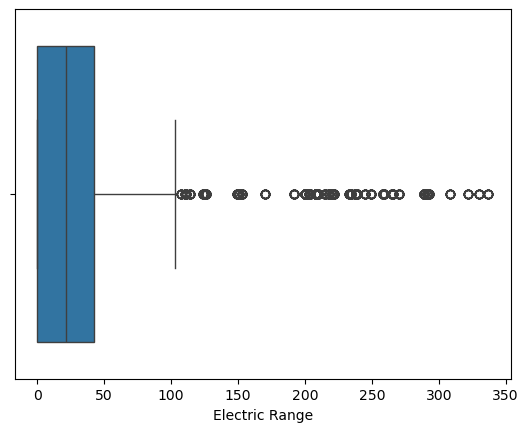

In [90]:
# Are there any outliers in electric range?
# check through boxplot 
sns.boxplot(x = data['Electric Range'])

In [91]:
# What is the range distribution by vehicle type?


In [92]:
## What is the range distribution by vehicle type?
# for using unstack - we must have two or more columns in group by function 
data.groupby(['Model Year', 'Electric Vehicle Type'])['Electric Range'].mean().unstack(fill_value= 0)


Electric Vehicle Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Model Year,,
1997,39.000000,0.000000
1998,58.000000,0.000000
1999,74.000000,0.000000
2000,58.000000,0.000000
2002,95.000000,0.000000
2003,95.000000,0.000000
2008,220.000000,0.000000
2010,245.000000,100.000000
2011,113.454545,35.000000


In [93]:
# What is the correlation between model year and electric range?
# SYNTAX FOR MULTIPLE COLUMNS 
'''data[['Model Year', 'Electric Range', 'Base MSRP']].corr()'''

data['Model Year'].corr(data['Electric Range'])


-0.41618006142950453

In [94]:
# gives negative correlattion 

## CAFV Eligibility


In [96]:
# What percent of vehicles are CAFV eligible?
(data[data['Clean Alternative Fuel Vehicle (CAFV) Eligibility']== 'Clean Alternative Fuel Vehicle Eligible'].shape[0] / data.shape[0])*100

 

39.883608147429676

In [97]:
# which cavf vehicles are newer 
data[data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Clean Alternative Fuel Vehicle Eligible']['Model Year'].value_counts().sort_values(ascending = False)


Model Year
2019    462
2020    447
2023    415
2018    355
2017    343
2022    305
2015    295
2016    292
2014    259
2024    255
2021    240
2013    224
2012    147
2011     39
2010     12
2008      9
2000      6
2002      2
1999      2
1998      1
1997      1
2003      1
Name: count, dtype: int64

In [98]:
# What is the average electric range for CAFV eligible vs not?
data.groupby('Clean Alternative Fuel Vehicle (CAFV) Eligibility')['Electric Range'].mean()


Clean Alternative Fuel Vehicle (CAFV) Eligibility
Clean Alternative Fuel Vehicle Eligible                         115.158317
Eligibility unknown as battery range has not been researched      0.000000
Not eligible due to low battery range                            19.549730
Name: Electric Range, dtype: float64

In [99]:
# What is the city-wise count of CAFV eligible vehicles?
data[data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Clean Alternative Fuel Vehicle Eligible']['City'].value_counts().sort_values(ascending = False)


City
Seattle       899
Bellevue      325
Vancouver     308
Kirkland      244
Redmond       116
             ... 
Clarkston       1
Waterville      1
Elma            1
Darrington      1
Bow             1
Name: count, Length: 195, dtype: int64

In [100]:
# Which makes are mostly CAFV eligible?
data[data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Clean Alternative Fuel Vehicle Eligible']['Make'].value_counts().sort_values(ascending = False)


Make
TESLA                   854
CHEVROLET               625
VOLVO                   370
BMW                     277
CHRYSLER                231
KIA                     225
TOYOTA                  209
HYUNDAI                 186
NISSAN                  165
FORD                    146
AUDI                    113
VOLKSWAGEN              101
HONDA                    81
SMART                    79
FIAT                     74
JAGUAR                   56
CADILLAC                 54
LEXUS                    52
MITSUBISHI               50
PORSCHE                  44
MERCEDES-BENZ            39
ALFA ROMEO               19
DODGE                    14
POLESTAR                 11
MINI                     11
FISKER                    9
LAND ROVER                7
AZURE DYNAMICS            5
TH!NK                     3
WHEEGO ELECTRIC CARS      2
Name: count, dtype: int64

## ADVANCE

In [102]:
# What are the top makes in vehicles with electric range > 300?
data[data['Electric Range'] > 300 ]['Make'].value_counts()

Make
TESLA    44
Name: count, dtype: int64

In [103]:
# list all cities where vehicles have range > 250 and are CAFV eligible.
c1 = data['Electric Range'] > 250 
c2 = data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Clean Alternative Fuel Vehicle Eligible'
data[c1&c2]['City'].value_counts()


City
Seattle          72
Bellevue         42
Kirkland         24
Vancouver        23
Sammamish        15
                 ..
Kalama            1
White Salmon      1
Yelm              1
Port Townsend     1
Sedro-Woolley     1
Name: count, Length: 73, dtype: int64

In [104]:
# What are the models launched after 2020 with range > 200?
c1 = data['Model Year'] > 2020 
c2 = data['Electric Range'] > 200
data[(c1&c2)]['Model'].value_counts()

Model
E-TRON              31
E-TRON SPORTBACK    22
PS2                 11
TAYCAN              11
Name: count, dtype: int64

In [105]:
data['Model']

DOL Vehicle ID
1593721           500
257167501     MODEL X
224071816        330E
260084653         R1S
253771913     MODEL 3
               ...   
187372433    PANAMERA
235108051        XC90
216929261      TAYCAN
260050724        XC40
239002144         C40
Name: Model, Length: 10310, dtype: object

In [106]:
# Which Make-Model-Year combos appeared hmore no of times?
data[['Make','Model','Model Year']].mode()


,Make,Model,Model Year
0,TESLA,MODEL S,2023


In [107]:
# data.groupby(['Make', 'Model', 'Model Year']).size().reset_index(name='Count').query('Count > 1')


In [108]:
# How many vehicles of a certain make are Plug-in Hybrid and CAFV eligible?
c1 = data['Electric Vehicle Type']== 'Plug-in Hybrid Electric Vehicle (PHEV)'
c2 = data['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] == 'Clean Alternative Fuel Vehicle Eligible'
data[c1&c2]['Make'].value_counts()

Make
CHEVROLET               443
VOLVO                   370
CHRYSLER                231
TOYOTA                  181
BMW                     167
KIA                     105
HYUNDAI                  89
HONDA                    81
FORD                     72
CADILLAC                 54
LEXUS                    52
MITSUBISHI               25
ALFA ROMEO               19
DODGE                    14
FISKER                    9
LAND ROVER                7
WHEEGO ELECTRIC CARS      2
Name: count, dtype: int64

## VIN / Unique Identifiers


In [110]:
# How many unique VINs are there?

data['VIN (1-10)'].nunique()

10310

In [111]:
# Are there any duplicated VINs?

data['VIN (1-10)'].duplicated().sum()

0

In [112]:
data

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
DOL Vehicle ID,,,,,,,,,,,,,,,,
1593721,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
257167501,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
224071816,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
260084653,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
253771913,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187372433,WP0CE2A78N,King,Vashon,WA,98070.0,2022,PORSCHE,PANAMERA,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,18,0,34.0,POINT (-122.46049 47.44873),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
235108051,YV4BR0CK5K,Pierce,Puyallup,WA,98372.0,2019,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,17,0,31.0,POINT (-122.28718 47.190465),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305394e+10
216929261,WP0CD2Y10N,Pierce,Gig Harbor,WA,98335.0,2022,PORSCHE,TAYCAN,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,26.0,POINT (-122.5835454 47.3234488),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305307e+10


In [113]:
# What is the DOL Vehicle ID range (min/max)?
'''Min_Range=data['DOL Vehicle ID'].min()
Max_Range=data['DOL Vehicle ID'].max()
Max_Range
Min_Range'''

"Min_Range=data['DOL Vehicle ID'].min()\nMax_Range=data['DOL Vehicle ID'].max()\nMax_Range\nMin_Range"

In [114]:
#Max_Range

In [115]:
#Min_Range

In [116]:
# Do any vehicles have missing IDs? --> NO 
#data['DOL Vehicle ID'].isnull().sum()


In [117]:
data.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [118]:
# Are the VINs or IDs unique across all rows?''' --> yes bcoz there value is same !!! 
#data[['VIN (1-10)','DOL Vehicle ID']].nunique()

## Temporal & Trend-Based


In [120]:
# How many EVs were registered each year?
# data.groupby('VIN (1-10)')['Model Year'].sum()

In [121]:
# What’s the trend in total electric range by year?
data.groupby('Model Year')['Electric Range'].mean()

Model Year
1997     39.000000
1998     58.000000
1999     74.000000
2000     58.000000
2002     95.000000
2003     95.000000
2008    220.000000
2010    220.833333
2011     79.256410
2012    100.455696
2013    101.731343
2014     65.052632
2015    104.602703
2016     78.906318
2017     85.483066
2018     75.926724
2019    119.221769
2020    132.093199
2021     28.555070
2022     10.849972
2023      8.875405
2024     15.304893
Name: Electric Range, dtype: float64

In [122]:
# How has Plug-in Hybrid popularity changed since 2015?
c1 = data['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)'
c2 = data['Model Year'] > 2015
new = data[c1&c2].groupby('Model Year').size()
new


Model Year
2016    221
2017    306
2018    470
2019    380
2020    405
2021    480
2022    696
2023    628
2024    382
dtype: int64

In [123]:
# DIFFERENT WAY 
'''phev_data = data[
    (data['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)') &
    (data['Model Year'] > 2015)
]

# Group by year and count
phev_trend = phev_data.groupby('Model Year').size()

# Display trend
print(phev_trend)'''

"phev_data = data[\n    (data['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)') &\n    (data['Model Year'] > 2015)\n]\n\n# Group by year and count\nphev_trend = phev_data.groupby('Model Year').size()\n\n# Display trend\nprint(phev_trend)"

In [124]:
# What is the average electric range per year?
data.groupby('Model Year')['Electric Range'].mean()


Model Year
1997     39.000000
1998     58.000000
1999     74.000000
2000     58.000000
2002     95.000000
2003     95.000000
2008    220.000000
2010    220.833333
2011     79.256410
2012    100.455696
2013    101.731343
2014     65.052632
2015    104.602703
2016     78.906318
2017     85.483066
2018     75.926724
2019    119.221769
2020    132.093199
2021     28.555070
2022     10.849972
2023      8.875405
2024     15.304893
Name: Electric Range, dtype: float64

In [125]:
# Are newer vehicles more likely to have higher ranges? ---> NO 
data.groupby('Model Year')['Electric Range'].mean().sort_values(ascending = True)


Model Year
2023      8.875405
2022     10.849972
2024     15.304893
2021     28.555070
1997     39.000000
1998     58.000000
2000     58.000000
2014     65.052632
1999     74.000000
2018     75.926724
2016     78.906318
2011     79.256410
2017     85.483066
2003     95.000000
2002     95.000000
2012    100.455696
2013    101.731343
2015    104.602703
2019    119.221769
2020    132.093199
2008    220.000000
2010    220.833333
Name: Electric Range, dtype: float64

In [126]:
data.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [127]:
data.to_csv("Cleaned US Electric Vehicle.csv", index = False)
print("Cleaned dataset saved as Cleaned US Electric Vehicle.csv")

Cleaned dataset saved as Cleaned US Electric Vehicle.csv


In [21]:
import pandas as pd

# Read the cleaned CSV file
data = pd.read_csv("Cleaned US Electric Vehicle.csv")

# Save it as an Excel file
data.to_excel("Cleaned US Electric Vehicle.xlsx", index=False)

print("Cleaned dataset saved as Cleaned US Electric Vehicle.xlsx")


Cleaned dataset saved as Cleaned US Electric Vehicle.xlsx


In [19]:
data

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,3C3CFFGE4E,Yakima,Yakima,WA,98902.0,2014,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,0,14.0,1593721,POINT (-120.524012 46.5973939),PACIFICORP,5.307700e+10
1,5YJXCBE40H,Thurston,Olympia,WA,98513.0,2017,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,200,0,2.0,257167501,POINT (-122.817545 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
2,3MW39FS03P,King,Renton,WA,98058.0,2023,BMW,330E,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,20,0,11.0,224071816,POINT (-122.1298876 47.4451257),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
3,7PDSGABA8P,Snohomish,Bothell,WA,98012.0,2023,RIVIAN,R1S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,260084653,POINT (-122.1873 47.820245),PUGET SOUND ENERGY INC,5.306105e+10
4,5YJ3E1EB8L,King,Kent,WA,98031.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322,0,33.0,253771913,POINT (-122.2012521 47.3931814),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166795,3FA6P0SU4D,Spokane,Spokane,WA,99223.0,2013,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19,0,6.0,239527123,POINT (-117.369705 47.62637),BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,5.306300e+10
166796,5YJYGDEE5M,King,Sammamish,WA,98074.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,45.0,148715479,POINT (-122.0313266 47.6285782),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
166797,7SAYGDEE5N,Snohomish,Mukilteo,WA,98275.0,2022,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,220504406,POINT (-122.299965 47.94171),PUGET SOUND ENERGY INC,5.306104e+10
166798,1G1RH6E43D,Lewis,Mossyrock,WA,98564.0,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,38,0,20.0,156418475,POINT (-122.487535 46.5290135),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.304197e+10


In [ ]:
categorical_cols = ['County', 'City', 'State', 'Make', 'Model', 
                    'Electric Vehicle Type', 'Electric Utility']
df = pd.get_dummies(us, columns=categorical_cols, drop_first=True)
